In [ ]:
#Descriptive Statistics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
merged_df = pd.read_csv("merged_data.csv")

In [4]:
merged_df["watch_time_sec"].describe()

count    499207.000000
mean         48.264063
std          39.555373
min           1.000000
25%          16.000000
50%          37.000000
75%          73.000000
max         180.000000
Name: watch_time_sec, dtype: float64

In [ ]:
#Distribution Analysis

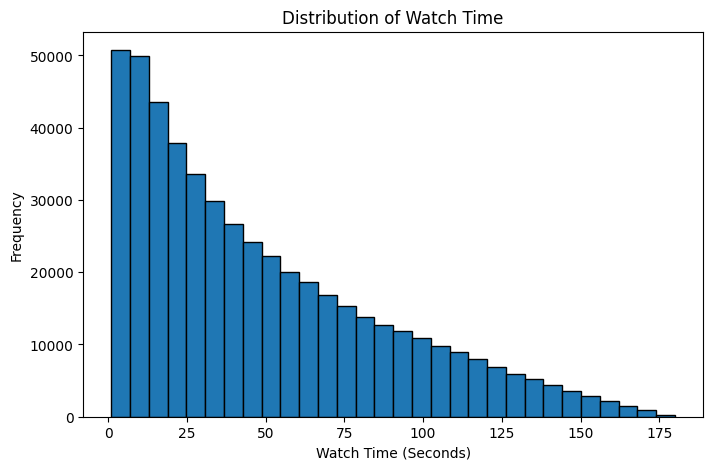

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    merged_df["watch_time_sec"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Watch Time")
plt.xlabel("Watch Time (Seconds)")
plt.ylabel("Frequency")

plt.show()

In [11]:
merged_df["watch_time_sec"].dtype

dtype('float64')

In [13]:
print(merged_df["watch_time_sec"].head())

0     31.0
1      NaN
2     61.0
3      NaN
4    117.0
Name: watch_time_sec, dtype: float64


In [14]:
print(merged_df["watch_time_sec"].isna().sum())

189525


In [15]:
merged_df["event_type"].value_counts()

event_type
View       499207
Like       124865
Comment     39915
Share       14853
Follow       9892
Name: count, dtype: int64

In [16]:
merged_df.groupby("event_type")["watch_time_sec"].agg(
    total_events="size",
    non_missing="count",
    missing=lambda x: x.isna().sum()
)

,total_events,non_missing,missing
event_type,,,
Comment,39915,0,39915
Follow,9892,0,9892
Like,124865,0,124865
Share,14853,0,14853
View,499207,499207,0


In [17]:
view_events = merged_df[
    merged_df["event_type"] == "View"
]

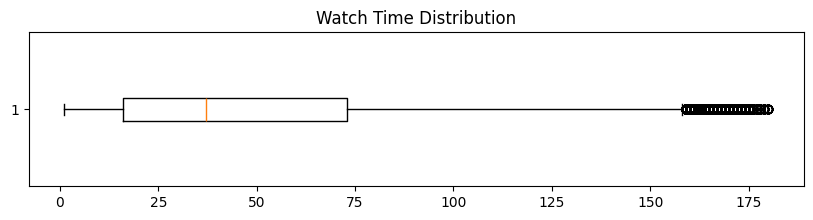

In [18]:
plt.figure(figsize=(10,2))

plt.boxplot(
    view_events["watch_time_sec"],
    vert=False
)

plt.title("Watch Time Distribution")

plt.show()

In [ ]:
#Correlation Analysis

In [19]:
correlation = merged_df["duration_sec"].corr(
    merged_df["watch_time_sec"]
)

print(correlation)

0.6212383583681883


In [20]:
correlation_matrix = merged_df[
    ["duration_sec", "watch_time_sec", "watch_completed"]
].corr()

print(correlation_matrix)

                 duration_sec  watch_time_sec  watch_completed
duration_sec         1.000000        0.621238        -0.021295
watch_time_sec       0.621238        1.000000         0.347747
watch_completed     -0.021295        0.347747         1.000000


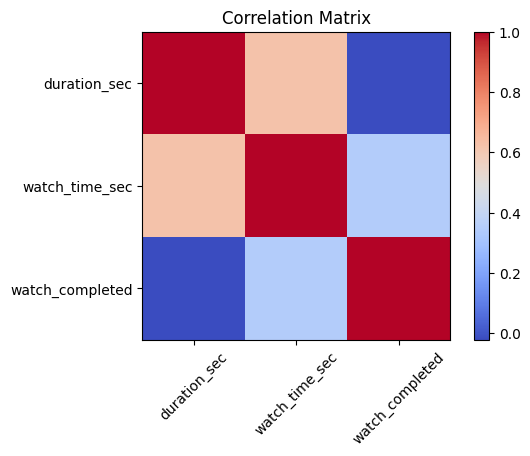

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(correlation_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
#Hypothesis Testing
#Gaming videos seem to have a higher average watch time than Education videos

In [27]:
gaming = merged_df[
    (merged_df["category"] == "Gaming") &
    (merged_df["event_type"] == "View")
]["watch_time_sec"]

education = merged_df[
    (merged_df["category"] == "Education") &
    (merged_df["event_type"] == "View")
]["watch_time_sec"]

In [28]:
from scipy.stats import ttest_ind

In [29]:
t_stat, p_value = ttest_ind(gaming, education)

In [30]:
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.910628844324858
P-value: 5.156568754363728e-19


In [31]:
print("Gaming Mean:", gaming.mean())
print("Education Mean:", education.mean())

Gaming Mean: 50.59747880895458
Education Mean: 48.35540949441917


In [ ]:
#Do users who complete a video watch significantly longer than users who do not complete the video?

In [39]:
completed = merged_df[
    (merged_df["watch_completed"] == 1) &
    (merged_df["event_type"] == "View")
]["watch_time_sec"]

not_completed = merged_df[
    (merged_df["watch_completed"] == 0) &
    (merged_df["event_type"] == "View")
]["watch_time_sec"]

In [40]:
print("Completed:", completed.shape)
print("Not Completed:", not_completed.shape)

Completed: (54420,)
Not Completed: (444787,)


In [41]:
t_stat, p_value = ttest_ind(completed, not_completed)

In [42]:
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 262.05424918274076
P-value: 0.0


In [43]:
print("Completed Mean:", completed.mean())
print("Not Completed Mean:", not_completed.mean())

Completed Mean: 87.58879088570379
Not Completed Mean: 43.45265486626183


In [44]:
#ANOVA
#Do any of these categories have different average watch times?

In [47]:
from scipy.stats import f_oneway

categories = merged_df["category"].unique()

groups = []

for category in categories:
    group = merged_df[
        (merged_df["category"] == category) &
        (merged_df["event_type"] == "View")
    ]["watch_time_sec"]

    groups.append(group)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 46.67357305466644
P-value: 7.786887920133855e-85


In [ ]:
#Chi-square
#Is the device type (Android/iPhone/Web) related to whether a user completes a video?

In [49]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    merged_df["device"],
    merged_df["watch_completed"]
)

In [50]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 0.04337678054122039
P-value: 0.9785451117249345
Degrees of Freedom: 2


In [51]:
from scipy.stats import sem

se = sem(
    merged_df[
        merged_df["event_type"] == "View"
    ]["watch_time_sec"]
)

print("Standard Error:", se)

Standard Error: 0.055984158387749366


In [52]:
from scipy.stats import norm

mean = merged_df[
    merged_df["event_type"] == "View"
]["watch_time_sec"].mean()

lower = mean - 1.96 * se
upper = mean + 1.96 * se

print("Mean:", mean)
print("95% Confidence Interval:")
print(lower, upper)

Mean: 48.26406280360652
95% Confidence Interval:
48.154333853166534 48.37379175404651


In [ ]:
#Random sampling and clt
#Even though watch_time_sec is right-skewed, the sample means become approximately normally distributed.


In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
watch_time = merged_df[
    merged_df["event_type"] == "View"
]["watch_time_sec"]

In [55]:
sample_means = []
for i in range(1000):

    sample = watch_time.sample(n=100)

    sample_means.append(sample.mean())

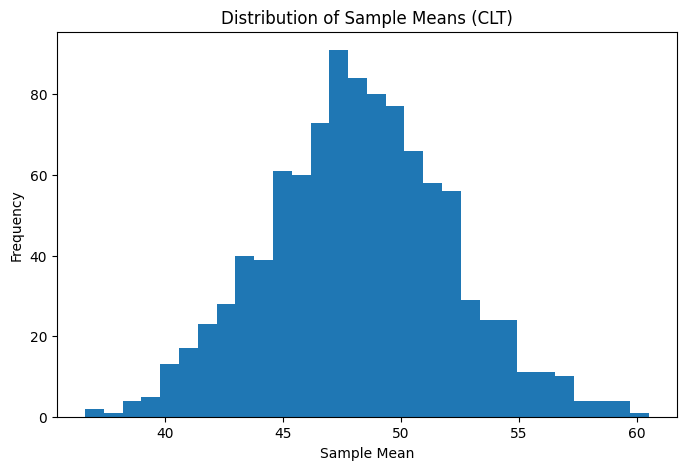

In [56]:
plt.figure(figsize=(8,5))

plt.hist(sample_means, bins=30)

plt.title("Distribution of Sample Means (CLT)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()